In [1]:
# ==============================================================================
# 14. Model Comparison (v1 vs v2 종합 비교)
# ==============================================================================
#
# 목적:
#   1. v1 vs v2 성능 종합 비교
#   2. Overfitting 개선 여부 확인
#   3. Threshold별 성능 비교
#   4. 최종 모델 선택 권장
# ==============================================================================

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

INPUT_DIR = '../data/processed'
MODEL_DIR = '../models'
REPORT_DIR = '../reports'

os.makedirs(REPORT_DIR, exist_ok=True)

print("=== 14. Model Comparison 시작 ===")

=== 14. Model Comparison 시작 ===


In [2]:
# ==============================================================================
# Step 2: 결과 파일 로드
# ==============================================================================

print("\nStep 2: 결과 파일 로드")

# --- v1 결과 ---
v1_files = [f for f in os.listdir(MODEL_DIR) if f.startswith('results_') and 'v2' not in f]
v1_file = sorted(v1_files)[-1]
v1_results = pd.read_csv(os.path.join(MODEL_DIR, v1_file))
print(f"✓ v1 결과: {v1_file}")

# --- v2 결과 ---
v2_files = [f for f in os.listdir(MODEL_DIR) if f.startswith('results_') and 'v2' in f]
v2_file = sorted(v2_files)[-1]
v2_results = pd.read_csv(os.path.join(MODEL_DIR, v2_file))
print(f"✓ v2 결과: {v2_file}")

# v1에서 XGBoost만 추출
v1_xgb = v1_results[v1_results['model'] == 'XGBoost'].copy()
v1_lgb = v1_results[v1_results['model'] == 'LightGBM'].copy()


Step 2: 결과 파일 로드
✓ v1 결과: results_20260107_222330.csv
✓ v2 결과: results_v2_lactate_special_20260108_004507.csv


In [3]:
# ==============================================================================
# Step 3: 성능 비교 테이블 생성
# ==============================================================================

print("\nStep 3: 성능 비교 테이블")

main_targets = ['death_next_24h', 'vent_next_24h', 'pressor_next_24h', 'composite_next_24h']

comparison_rows = []

for target in main_targets:
    row = {'target': target}
    
    # v1 XGBoost
    v1_xgb_row = v1_xgb[v1_xgb['target'] == target]
    if len(v1_xgb_row) > 0:
        row['v1_xgb_train'] = v1_xgb_row['train_auroc'].values[0]
        row['v1_xgb_val'] = v1_xgb_row['val_auroc'].values[0]
        row['v1_xgb_test'] = v1_xgb_row['test_auroc'].values[0]
        row['v1_xgb_auprc'] = v1_xgb_row['test_auprc'].values[0]
        row['v1_xgb_f1'] = v1_xgb_row['test_f1'].values[0]
        row['v1_xgb_gap'] = row['v1_xgb_train'] - row['v1_xgb_val']
    
    # v1 LightGBM
    v1_lgb_row = v1_lgb[v1_lgb['target'] == target]
    if len(v1_lgb_row) > 0:
        row['v1_lgb_train'] = v1_lgb_row['train_auroc'].values[0]
        row['v1_lgb_val'] = v1_lgb_row['val_auroc'].values[0]
        row['v1_lgb_test'] = v1_lgb_row['test_auroc'].values[0]
        row['v1_lgb_gap'] = row['v1_lgb_train'] - row['v1_lgb_val']
    
    # v2 XGBoost
    v2_xgb_row = v2_results[v2_results['target'] == target]
    if len(v2_xgb_row) > 0:
        row['v2_xgb_train'] = v2_xgb_row['train_auroc'].values[0]
        row['v2_xgb_val'] = v2_xgb_row['val_auroc'].values[0]
        row['v2_xgb_test'] = v2_xgb_row['test_auroc'].values[0]
        row['v2_xgb_auprc'] = v2_xgb_row['test_auprc'].values[0]
        row['v2_xgb_f1'] = v2_xgb_row['test_f1'].values[0]
        row['v2_xgb_gap'] = row['v2_xgb_train'] - row['v2_xgb_val']
        
        # clinical threshold 결과 (v2에만 있음)
        if 'clinical_threshold' in v2_xgb_row.columns:
            row['v2_clinical_threshold'] = v2_xgb_row['clinical_threshold'].values[0]
            row['v2_clinical_recall'] = v2_xgb_row['clinical_recall'].values[0]
            row['v2_clinical_precision'] = v2_xgb_row['clinical_precision'].values[0]
    
    comparison_rows.append(row)

df_comparison = pd.DataFrame(comparison_rows)


Step 3: 성능 비교 테이블


In [4]:
# ==============================================================================
# Step 4: Overfitting 비교 (Train-Val Gap)
# ==============================================================================

print("\n" + "="*70)
print("Overfitting 비교 (Train-Val Gap)")
print("="*70)

print(f"\n{'Target':<22} {'v1 XGB':<10} {'v1 LGB':<10} {'v2 XGB':<10} {'v1→v2 개선':<12}")
print("-" * 70)

total_v1_gap = 0
total_v2_gap = 0

for _, row in df_comparison.iterrows():
    v1_xgb_gap = row.get('v1_xgb_gap', 0)
    v1_lgb_gap = row.get('v1_lgb_gap', 0)
    v2_xgb_gap = row.get('v2_xgb_gap', 0)
    
    improvement = v1_xgb_gap - v2_xgb_gap
    
    if improvement > 0.03:
        status = "✅ 크게 개선"
    elif improvement > 0:
        status = "🟡 소폭 개선"
    else:
        status = "❌ 악화"
    
    print(f"{row['target']:<22} {v1_xgb_gap:<10.4f} {v1_lgb_gap:<10.4f} {v2_xgb_gap:<10.4f} {status}")
    
    total_v1_gap += v1_xgb_gap
    total_v2_gap += v2_xgb_gap

avg_improvement = (total_v1_gap - total_v2_gap) / len(df_comparison)
print("-" * 70)
print(f"{'평균':<22} {total_v1_gap/len(df_comparison):<10.4f} {'':<10} {total_v2_gap/len(df_comparison):<10.4f} Gap 평균 {avg_improvement:+.4f}")


Overfitting 비교 (Train-Val Gap)

Target                 v1 XGB     v1 LGB     v2 XGB     v1→v2 개선    
----------------------------------------------------------------------
death_next_24h         0.0944     0.1310     0.0606     ✅ 크게 개선
vent_next_24h          0.1539     0.2036     0.0753     ✅ 크게 개선
pressor_next_24h       0.1120     0.1737     0.0663     ✅ 크게 개선
composite_next_24h     0.1041     0.1460     0.0484     ✅ 크게 개선
----------------------------------------------------------------------
평균                     0.1161                0.0627     Gap 평균 +0.0535


In [5]:
# ==============================================================================
# Step 5: Test 성능 비교 (AUROC, AUPRC, F1)
# ==============================================================================

print("\n" + "="*70)
print("Test AUROC 비교")
print("="*70)

print(f"\n{'Target':<22} {'v1 XGB':<10} {'v1 LGB':<10} {'v2 XGB':<10} {'v1→v2 변화':<12}")
print("-" * 70)

for _, row in df_comparison.iterrows():
    v1_xgb = row.get('v1_xgb_test', 0)
    v1_lgb = row.get('v1_lgb_test', 0)
    v2_xgb = row.get('v2_xgb_test', 0)
    
    change = v2_xgb - v1_xgb
    
    if change > 0.005:
        status = "✅ 개선"
    elif change > -0.005:
        status = "➖ 유지"
    else:
        status = "❌ 하락"
    
    print(f"{row['target']:<22} {v1_xgb:<10.4f} {v1_lgb:<10.4f} {v2_xgb:<10.4f} {status} ({change:+.4f})")

# --- AUPRC ---
print("\n" + "="*70)
print("Test AUPRC 비교")
print("="*70)

print(f"\n{'Target':<22} {'v1 XGB':<10} {'v2 XGB':<10} {'변화':<12}")
print("-" * 50)

for _, row in df_comparison.iterrows():
    v1_auprc = row.get('v1_xgb_auprc', 0)
    v2_auprc = row.get('v2_xgb_auprc', 0)
    
    change = v2_auprc - v1_auprc
    
    if change > 0.01:
        status = "✅ 개선"
    elif change > -0.01:
        status = "➖ 유지"
    else:
        status = "❌ 하락"
    
    print(f"{row['target']:<22} {v1_auprc:<10.4f} {v2_auprc:<10.4f} {status} ({change:+.4f})")


Test AUROC 비교

Target                 v1 XGB     v1 LGB     v2 XGB     v1→v2 변화    
----------------------------------------------------------------------
death_next_24h         0.9275     0.9224     0.9302     ➖ 유지 (+0.0027)
vent_next_24h          0.7533     0.7433     0.7655     ✅ 개선 (+0.0121)
pressor_next_24h       0.8219     0.8067     0.8272     ✅ 개선 (+0.0053)
composite_next_24h     0.7859     0.7854     0.7830     ➖ 유지 (-0.0029)

Test AUPRC 비교

Target                 v1 XGB     v2 XGB     변화          
--------------------------------------------------
death_next_24h         0.2694     0.3020     ✅ 개선 (+0.0326)
vent_next_24h          0.1450     0.1420     ➖ 유지 (-0.0030)
pressor_next_24h       0.0836     0.0824     ➖ 유지 (-0.0012)
composite_next_24h     0.2185     0.2046     ❌ 하락 (-0.0140)


In [6]:
# ==============================================================================
# Step 6: Clinical Threshold 분석 (v2)
# ==============================================================================

print("\n" + "="*70)
print("Clinical Threshold 분석 (v2 - Recall≥70% 기준)")
print("="*70)

if 'v2_clinical_threshold' in df_comparison.columns:
    print(f"\n{'Target':<22} {'Threshold':<12} {'Recall':<10} {'Precision':<10}")
    print("-" * 55)
    
    for _, row in df_comparison.iterrows():
        threshold = row.get('v2_clinical_threshold', 'N/A')
        recall = row.get('v2_clinical_recall', 'N/A')
        precision = row.get('v2_clinical_precision', 'N/A')
        
        if isinstance(threshold, float):
            print(f"{row['target']:<22} {threshold:<12.2f} {recall:<10.3f} {precision:<10.3f}")
        else:
            print(f"{row['target']:<22} {'N/A':<12} {'N/A':<10} {'N/A':<10}")
else:
    print("\n  ⚠️ Clinical threshold 정보 없음 (v2 결과에 포함되지 않음)")


Clinical Threshold 분석 (v2 - Recall≥70% 기준)

Target                 Threshold    Recall     Precision 
-------------------------------------------------------
death_next_24h         0.60         0.742      0.062     
vent_next_24h          0.40         0.810      0.046     
pressor_next_24h       0.50         0.704      0.042     
composite_next_24h     0.40         0.806      0.070     



Step 7: 시각화


/var/folders/75/d2d6xns94fvg3j_nt83l63qw0000gn/T/ipykernel_16093/2353436522.py:75: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/75/d2d6xns94fvg3j_nt83l63qw0000gn/T/ipykernel_16093/2353436522.py:75: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/75/d2d6xns94fvg3j_nt83l63qw0000gn/T/ipykernel_16093/2353436522.py:75: UserWarning: Glyph 45230 (\N{HANGUL SYLLABLE NAJ}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/75/d2d6xns94fvg3j_nt83l63qw0000gn/T/ipykernel_16093/2353436522.py:75: UserWarning: Glyph 51012 (\N{HANGUL SYLLABLE EUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/75/d2d6xns94fvg3j_nt83l63qw0000gn/T/ipykernel_16093/2353436522.py:75: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/75/d2d6xns94fvg3j_nt83l63qw0000gn/T/ipykerne

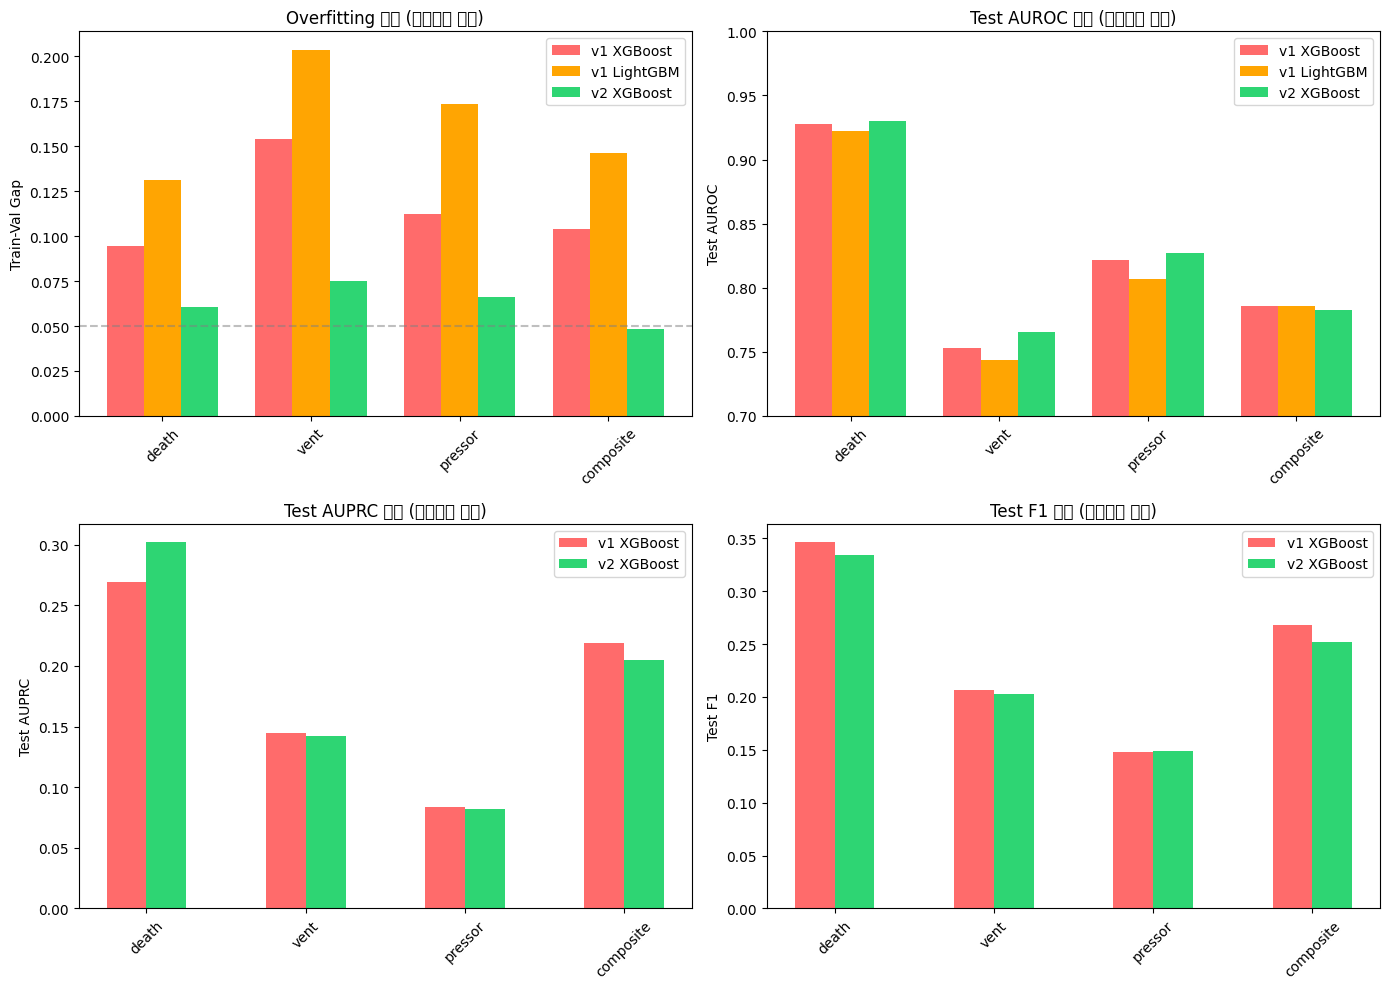

✓ 저장: ../reports/model_comparison_v1_vs_v2.png


In [7]:
# ==============================================================================
# Step 7: 시각화 (v1 vs v2 비교 차트)
# ==============================================================================

print("\nStep 7: 시각화")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

targets = df_comparison['target'].tolist()
x = np.arange(len(targets))
width = 0.25

# --- (1) Train-Val Gap 비교 ---
ax1 = axes[0, 0]
v1_xgb_gaps = df_comparison['v1_xgb_gap'].tolist()
v1_lgb_gaps = df_comparison['v1_lgb_gap'].tolist()
v2_xgb_gaps = df_comparison['v2_xgb_gap'].tolist()

bars1 = ax1.bar(x - width, v1_xgb_gaps, width, label='v1 XGBoost', color='#ff6b6b')
bars2 = ax1.bar(x, v1_lgb_gaps, width, label='v1 LightGBM', color='#ffa502')
bars3 = ax1.bar(x + width, v2_xgb_gaps, width, label='v2 XGBoost', color='#2ed573')

ax1.set_ylabel('Train-Val Gap')
ax1.set_title('Overfitting 비교 (낮을수록 좋음)')
ax1.set_xticks(x)
ax1.set_xticklabels([t.replace('_next_24h', '') for t in targets], rotation=45)
ax1.legend()
ax1.axhline(y=0.05, color='gray', linestyle='--', alpha=0.5, label='목표선')

# --- (2) Test AUROC 비교 ---
ax2 = axes[0, 1]
v1_xgb_auroc = df_comparison['v1_xgb_test'].tolist()
v1_lgb_auroc = df_comparison['v1_lgb_test'].tolist()
v2_xgb_auroc = df_comparison['v2_xgb_test'].tolist()

bars1 = ax2.bar(x - width, v1_xgb_auroc, width, label='v1 XGBoost', color='#ff6b6b')
bars2 = ax2.bar(x, v1_lgb_auroc, width, label='v1 LightGBM', color='#ffa502')
bars3 = ax2.bar(x + width, v2_xgb_auroc, width, label='v2 XGBoost', color='#2ed573')

ax2.set_ylabel('Test AUROC')
ax2.set_title('Test AUROC 비교 (높을수록 좋음)')
ax2.set_xticks(x)
ax2.set_xticklabels([t.replace('_next_24h', '') for t in targets], rotation=45)
ax2.legend()
ax2.set_ylim(0.7, 1.0)

# --- (3) Test AUPRC 비교 ---
ax3 = axes[1, 0]
v1_xgb_auprc = df_comparison['v1_xgb_auprc'].tolist()
v2_xgb_auprc = df_comparison['v2_xgb_auprc'].tolist()

bars1 = ax3.bar(x - width/2, v1_xgb_auprc, width, label='v1 XGBoost', color='#ff6b6b')
bars2 = ax3.bar(x + width/2, v2_xgb_auprc, width, label='v2 XGBoost', color='#2ed573')

ax3.set_ylabel('Test AUPRC')
ax3.set_title('Test AUPRC 비교 (높을수록 좋음)')
ax3.set_xticks(x)
ax3.set_xticklabels([t.replace('_next_24h', '') for t in targets], rotation=45)
ax3.legend()

# --- (4) F1 Score 비교 ---
ax4 = axes[1, 1]
v1_xgb_f1 = df_comparison['v1_xgb_f1'].tolist()
v2_xgb_f1 = df_comparison['v2_xgb_f1'].tolist()

bars1 = ax4.bar(x - width/2, v1_xgb_f1, width, label='v1 XGBoost', color='#ff6b6b')
bars2 = ax4.bar(x + width/2, v2_xgb_f1, width, label='v2 XGBoost', color='#2ed573')

ax4.set_ylabel('Test F1')
ax4.set_title('Test F1 비교 (높을수록 좋음)')
ax4.set_xticks(x)
ax4.set_xticklabels([t.replace('_next_24h', '') for t in targets], rotation=45)
ax4.legend()

plt.tight_layout()

chart_path = os.path.join(REPORT_DIR, 'model_comparison_v1_vs_v2.png')
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ 저장: {chart_path}")

In [9]:
# ==============================================================================
# Step 8: 최종 권장
# ==============================================================================

print("\n" + "="*70)
print("최종 권장")
print("="*70)

# 평가 기준
avg_v1_gap = df_comparison['v1_xgb_gap'].mean()
avg_v2_gap = df_comparison['v2_xgb_gap'].mean()
avg_v1_auroc = df_comparison['v1_xgb_test'].mean()
avg_v2_auroc = df_comparison['v2_xgb_test'].mean()
avg_v1_auprc = df_comparison['v1_xgb_auprc'].mean()
avg_v2_auprc = df_comparison['v2_xgb_auprc'].mean()

gap_improved = avg_v2_gap < avg_v1_gap
auroc_maintained = avg_v2_auroc >= avg_v1_auroc - 0.01
auprc_maintained = avg_v2_auprc >= avg_v1_auprc - 0.01

print(f"\n=== 평가 결과 ===")
print(f"  Overfitting 개선: {'✅' if gap_improved else '❌'} (Gap: {avg_v1_gap:.4f} → {avg_v2_gap:.4f})")
print(f"  AUROC 유지/개선:  {'✅' if auroc_maintained else '❌'} ({avg_v1_auroc:.4f} → {avg_v2_auroc:.4f})")
print(f"  AUPRC 유지/개선:  {'✅' if auprc_maintained else '❌'} ({avg_v1_auprc:.4f} → {avg_v2_auprc:.4f})")

print(f"\n=== 최종 권장 ===")
if gap_improved and auroc_maintained:
    print("  🎉 v2 XGBoost 모델 채택 권장")
    print("  - Overfitting 개선됨")
    print("  - 성능 유지됨")
    print("  - 일반화 능력 향상 기대")
elif gap_improved:
    print("  🟡 v2 모델 조건부 채택")
    print("  - Overfitting 개선됨")
    print("  - 성능 소폭 하락 → Trade-off 수용 가능 여부 검토")
else:
    print("  ❌ 추가 튜닝 필요")
    print("  - 다른 하이퍼파라미터 조합 시도")

print(f"\n=== 타겟별 권장 모델 ===")
for _, row in df_comparison.iterrows():
    v1_auroc = row.get('v1_xgb_test', 0)
    v2_auroc = row.get('v2_xgb_test', 0)
    v1_gap = row.get('v1_xgb_gap', 0)
    v2_gap = row.get('v2_xgb_gap', 0)
    
    # v2가 더 나은 경우
    if v2_gap < v1_gap and v2_auroc >= v1_auroc - 0.01:
        recommendation = "v2 ✅"
    elif v2_auroc > v1_auroc + 0.01:
        recommendation = "v2 ✅"
    else:
        recommendation = "v1 🟡"
    
    print(f"  {row['target']}: {recommendation}")

# --- 저장 ---
comparison_path = os.path.join(REPORT_DIR, 'model_comparison_summary.csv')
df_comparison.to_csv(comparison_path, index=False)
print(f"\n✓ 비교 결과 저장: {comparison_path}")

print("\n=== 14. Model Comparison 완료 ===")


최종 권장

=== 평가 결과 ===
  Overfitting 개선: ✅ (Gap: 0.1161 → 0.0627)
  AUROC 유지/개선:  ✅ (0.8221 → 0.8265)
  AUPRC 유지/개선:  ✅ (0.1791 → 0.1827)

=== 최종 권장 ===
  🎉 v2 XGBoost 모델 채택 권장
  - Overfitting 개선됨
  - 성능 유지됨
  - 일반화 능력 향상 기대

=== 타겟별 권장 모델 ===
  death_next_24h: v2 ✅
  vent_next_24h: v2 ✅
  pressor_next_24h: v2 ✅
  composite_next_24h: v2 ✅

✓ 비교 결과 저장: ../reports/model_comparison_summary.csv

=== 14. Model Comparison 완료 ===
